# 💻 Laptop Price Prediction & Recommendation System
### Steps:
1. Install packages
2. Mount Google Drive (dataset loads automatically!)
3. Preprocess & Train ML model
4. Start Flask API
5. Get public URL via ngrok
6. Open Frontend HTML in browser

**To present: Just press `Runtime → Run All` and wait ~1 minute!**

## ✅ CELL 1 — Install Required Libraries

In [ ]:
!pip install flask flask-cors pyngrok scikit-learn pandas numpy --quiet

## ✅ CELL 2 — Mount Google Drive & Load Dataset
> ⚠️ Make sure `laptops.csv` is uploaded to your **Google Drive (My Drive)** root folder before running.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ✏️ If your file is inside a folder in Drive, update the path below
# Example: '/content/drive/MyDrive/project/laptops.csv'
DATASET_PATH = '/content/drive/MyDrive/laptops.csv'

df = pd.read_csv(DATASET_PATH)
print('✅ Dataset loaded from Google Drive!')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Mounted at /content/drive
✅ Dataset loaded from Google Drive!
Shape: (984, 12)
Columns: ['Unnamed: 0', 'img_link', 'name', 'price(in Rs.)', 'processor', 'ram', 'os', 'storage', 'display(in inch)', 'rating', 'no_of_ratings', 'no_of_reviews']


,Unnamed: 0,img_link,name,price(in Rs.),processor,ram,os,storage,display(in inch),rating,no_of_ratings,no_of_reviews
0,0,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo Intel Core i5 11th Gen,62990,Intel Core i5 Processor (11th Gen),16 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,15.6,4.5,14.0,1.0
1,1,https://rukminim1.flixcart.com/image/312/312/x...,Lenovo V15 G2 Core i3 11th Gen,37500,Intel Core i3 Processor (11th Gen),8 GB DDR4 RAM,64 bit Windows 11 Operating System,1 TB HDD|256 GB SSD,15.6,4.4,53.0,3.0
2,2,https://rukminim1.flixcart.com/image/312/312/l...,ASUS TUF Gaming F15 Core i5 10th Gen,49990,Intel Core i5 Processor (10th Gen),8 GB DDR4 RAM,Windows 11 Operating System,512 GB SSD,15.6,4.4,4733.0,463.0


## ✅ CELL 3 — Data Preprocessing

In [ ]:
import re

def preprocess(df):
    df = df.copy()

    df['rating'] = df['rating'].fillna(df['rating'].median())
    df['no_of_ratings'] = df['no_of_ratings'].fillna(0)
    df['no_of_reviews'] = df['no_of_reviews'].fillna(0)

    def extract_ram(r):
        m = re.search(r'(\d+)\s*GB', str(r))
        return int(m.group(1)) if m else 8

    def extract_storage(s):
        s = str(s)
        total = 0
        for match in re.finditer(r'(\d+(?:\.\d+)?)\s*(TB|GB)', s, re.IGNORECASE):
            val = float(match.group(1))
            unit = match.group(2).upper()
            total += val * 1000 if unit == 'TB' else val
        return total if total > 0 else 256

    def extract_processor_brand(p):
        p = str(p).lower()
        if 'intel' in p: return 'Intel'
        elif 'amd' in p: return 'AMD'
        elif 'apple' in p: return 'Apple'
        else: return 'Other'

    def extract_processor_tier(p):
        p = str(p).lower()
        if 'i9' in p or 'm2' in p: return 5
        elif 'i7' in p or 'm1' in p or 'ryzen 7' in p: return 4
        elif 'i5' in p or 'ryzen 5' in p: return 3
        elif 'i3' in p or 'ryzen 3' in p: return 2
        else: return 1

    def storage_type(s):
        s = str(s).lower()
        if 'ssd' in s and 'hdd' in s: return 2
        elif 'ssd' in s: return 3
        elif 'hdd' in s: return 1
        else: return 2

    def extract_os(o):
        o = str(o).lower()
        if 'windows 11' in o: return 'Windows 11'
        elif 'windows 10' in o: return 'Windows 10'
        elif 'mac' in o or 'macos' in o: return 'macOS'
        elif 'dos' in o: return 'DOS'
        elif 'ubuntu' in o or 'linux' in o: return 'Linux'
        else: return 'Other'

    df['ram_gb'] = df['ram'].apply(extract_ram)
    df['storage_gb'] = df['storage'].apply(extract_storage)
    df['storage_type_score'] = df['storage'].apply(storage_type)
    df['processor_brand'] = df['processor'].apply(extract_processor_brand)
    df['processor_tier'] = df['processor'].apply(extract_processor_tier)
    df['os_clean'] = df['os'].apply(extract_os)

    return df

df = preprocess(df)
print('✅ Preprocessing done!')
df[['name','ram_gb','storage_gb','processor_tier','os_clean','price(in Rs.)']].head()

✅ Preprocessing done!


,name,ram_gb,storage_gb,processor_tier,os_clean,price(in Rs.)
0,Lenovo Intel Core i5 11th Gen,16,512.0,3,Windows 11,62990
1,Lenovo V15 G2 Core i3 11th Gen,8,1256.0,2,Windows 11,37500
2,ASUS TUF Gaming F15 Core i5 10th Gen,8,512.0,3,Windows 11,49990
3,ASUS VivoBook 15 (2022) Core i3 10th Gen,8,512.0,2,Windows 11,33990
4,Lenovo Athlon Dual Core,4,256.0,1,DOS,18990


## ✅ CELL 4 — Train ML Model (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import pickle

le_brand = LabelEncoder()
le_os = LabelEncoder()
df['processor_brand_enc'] = le_brand.fit_transform(df['processor_brand'])
df['os_enc'] = le_os.fit_transform(df['os_clean'])

feature_cols = ['ram_gb', 'storage_gb', 'storage_type_score',
                'processor_brand_enc', 'processor_tier',
                'os_enc', 'display(in inch)', 'rating']

X = df[feature_cols]
y = df['price(in Rs.)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

preds = model.predict(X_test)
r2  = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f'✅ Model Trained!')
print(f'R² Score : {r2:.4f}  ({r2*100:.1f}% accuracy)')
print(f'MAE      : ₹{mae:,.0f}')

with open('model.pkl',    'wb') as f: pickle.dump(model,    f)
with open('le_brand.pkl', 'wb') as f: pickle.dump(le_brand, f)
with open('le_os.pkl',    'wb') as f: pickle.dump(le_os,    f)

print('✅ Model & encoders saved!')

✅ Model Trained!
R² Score : 0.8428  (84.3% accuracy)
MAE      : ₹14,020
✅ Model & encoders saved!


In [ ]:
## ✅ CELL 5 — EDA Charts

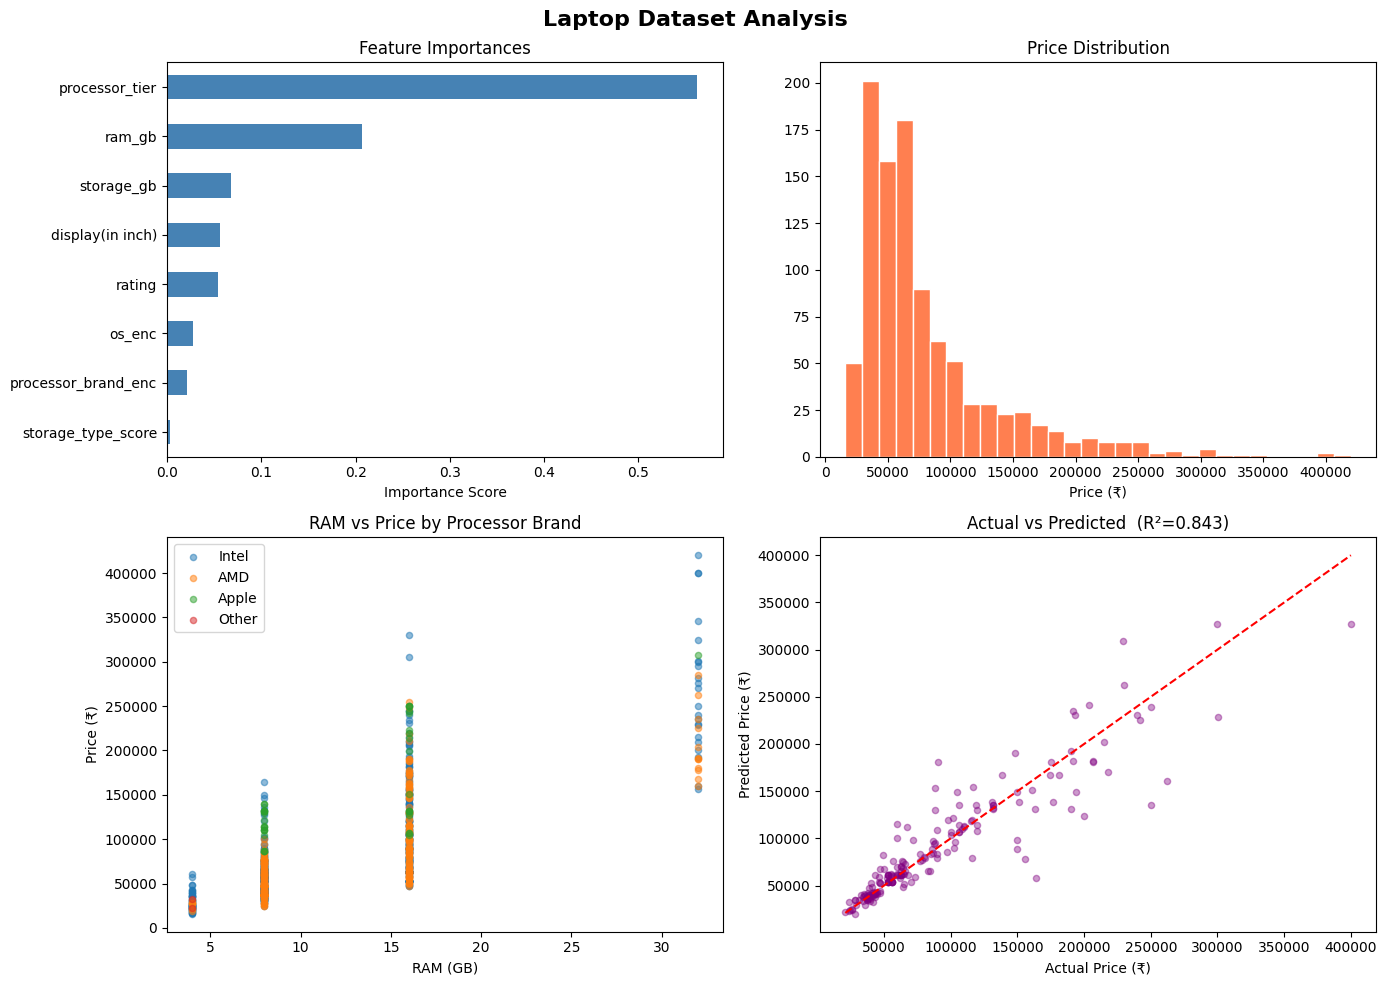

✅ Charts displayed!


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Laptop Dataset Analysis', fontsize=16, fontweight='bold')

# Feature importances
import pandas as pd
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Feature Importances')
axes[0,0].set_xlabel('Importance Score')

# Price distribution
axes[0,1].hist(df['price(in Rs.)'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Price Distribution')
axes[0,1].set_xlabel('Price (₹)')

# RAM vs Price by brand
for brand in df['processor_brand'].unique():
    sub = df[df['processor_brand'] == brand]
    axes[1,0].scatter(sub['ram_gb'], sub['price(in Rs.)'], label=brand, alpha=0.5, s=20)
axes[1,0].set_title('RAM vs Price by Processor Brand')
axes[1,0].set_xlabel('RAM (GB)')
axes[1,0].set_ylabel('Price (₹)')
axes[1,0].legend()

# Actual vs Predicted
axes[1,1].scatter(y_test, preds, alpha=0.4, color='purple', s=20)
axes[1,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1,1].set_title(f'Actual vs Predicted  (R²={r2:.3f})')
axes[1,1].set_xlabel('Actual Price (₹)')
axes[1,1].set_ylabel('Predicted Price (₹)')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Charts displayed!')

## ✅ CELL 6 — Save Cleaned Dataset

In [ ]:
df_save = df[['name', 'price(in Rs.)', 'processor', 'processor_brand', 'processor_tier',
              'ram', 'ram_gb', 'os', 'os_clean', 'storage', 'storage_gb',
              'display(in inch)', 'rating', 'img_link',
              'processor_brand_enc', 'os_enc', 'storage_type_score']].copy()

df_save.to_csv('laptops_clean.csv', index=False)
print('✅ Clean dataset saved:', df_save.shape)
df_save.head(2)

✅ Clean dataset saved: (984, 17)


,name,price(in Rs.),processor,processor_brand,processor_tier,ram,ram_gb,os,os_clean,storage,storage_gb,display(in inch),rating,img_link,processor_brand_enc,os_enc,storage_type_score
0,Lenovo Intel Core i5 11th Gen,62990,Intel Core i5 Processor (11th Gen),Intel,3,16 GB DDR4 RAM,16,Windows 11 Operating System,Windows 11,512 GB SSD,512.0,15.6,4.5,https://rukminim1.flixcart.com/image/312/312/x...,2,3,3
1,Lenovo V15 G2 Core i3 11th Gen,37500,Intel Core i3 Processor (11th Gen),Intel,2,8 GB DDR4 RAM,8,64 bit Windows 11 Operating System,Windows 11,1 TB HDD|256 GB SSD,1256.0,15.6,4.4,https://rukminim1.flixcart.com/image/312/312/x...,2,3,2


## ✅ CELL 7 — Write Flask API (app.py)

In [ ]:
flask_code = '''
from flask import Flask, request, jsonify
from flask_cors import CORS
import pandas as pd
import numpy as np
import pickle
import re

app = Flask(__name__)
CORS(app)

with open("model.pkl",    "rb") as f: model    = pickle.load(f)
with open("le_brand.pkl", "rb") as f: le_brand = pickle.load(f)
with open("le_os.pkl",    "rb") as f: le_os    = pickle.load(f)

df = pd.read_csv("laptops_clean.csv")

PROCESSOR_TIER = {
    "Intel Core i9": 5, "Apple M2": 5,
    "Intel Core i7": 4, "AMD Ryzen 7": 4, "Apple M1": 4,
    "Intel Core i5": 3, "AMD Ryzen 5": 3,
    "Intel Core i3": 2, "AMD Ryzen 3": 2,
    "Intel Celeron": 1, "AMD Athlon": 1,
}

def get_processor_tier(proc):
    for k, v in PROCESSOR_TIER.items():
        if k.lower() in proc.lower():
            return v
    return 2

def get_processor_brand(proc):
    proc = proc.lower()
    if "intel" in proc: return "Intel"
    elif "amd"  in proc: return "AMD"
    elif "apple" in proc: return "Apple"
    else: return "Other"

def safe_encode(le, value):
    if value in le.classes_:
        return le.transform([value])[0]
    return le.transform([le.classes_[0]])[0]

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.json
        ram_gb             = int(data.get("ram", 8))
        storage_gb         = int(data.get("storage", 512))
        storage_type_score = int(data.get("storage_type", 3))
        processor          = data.get("processor", "Intel Core i5")
        os_clean           = data.get("os", "Windows 11")
        display            = float(data.get("display", 15.6))
        rating             = float(data.get("rating", 4.0))

        proc_brand     = get_processor_brand(processor)
        proc_tier      = get_processor_tier(processor)
        proc_brand_enc = safe_encode(le_brand, proc_brand)
        os_enc         = safe_encode(le_os, os_clean)

        features = [[ram_gb, storage_gb, storage_type_score,
                     proc_brand_enc, proc_tier, os_enc, display, rating]]

        predicted_price = model.predict(features)[0]
        return jsonify({
            "predicted_price": round(float(predicted_price), 2),
            "formatted": f"\u20b9{int(predicted_price):,}",
            "status": "success"
        })
    except Exception as e:
        return jsonify({"error": str(e), "status": "error"}), 400

@app.route("/recommend", methods=["POST"])
def recommend():
    try:
        data      = request.json
        budget    = int(data.get("budget", 50000))
        use_case  = data.get("use_case", "general")
        min_ram   = int(data.get("min_ram", 8))
        pref_os   = data.get("os", "any")

        filtered = df[(df["price(in Rs.)"] <= budget * 1.1) &
                      (df["price(in Rs.)"] >= budget * 0.5) &
                      (df["ram_gb"] >= min_ram)].copy()

        if pref_os != "any":
            os_f = filtered[filtered["os_clean"].str.lower() == pref_os.lower()]
            if len(os_f) > 0:
                filtered = os_f

        def score_laptop(row):
            score  = row["processor_tier"] * 20
            score += min(row["ram_gb"] / 4, 10) * 5
            score += min(row["storage_gb"] / 100, 10) * 2
            score += row["storage_type_score"] * 5
            score += row["rating"] * 10 if pd.notna(row["rating"]) else 0
            score -= abs(1 - row["price(in Rs.)"]/budget) * 30
            if use_case == "gaming":
                if row["processor_brand"] in ["Intel","AMD"]: score += 15
                if row["ram_gb"] >= 16: score += 20
            elif use_case == "student":
                if row["price(in Rs.)"] < budget * 0.8: score += 15
            elif use_case == "office":
                if "windows" in str(row["os_clean"]).lower(): score += 10
            return score

        if filtered.empty:
            filtered = df[df["price(in Rs.)"] <= budget * 1.1].copy()

        filtered["score"] = filtered.apply(score_laptop, axis=1)
        top = filtered.nlargest(5, "score")

        results = []
        for _, row in top.iterrows():
            results.append({
                "name"     : row["name"],
                "price"    : f"\u20b9{int(row['price(in Rs.)']):,}",
                "price_val": int(row["price(in Rs.)"]),
                "processor": row["processor"],
                "ram"      : row["ram"],
                "storage"  : row["storage"],
                "os"       : row["os_clean"],
                "display"  : row["display(in inch)"],
                "rating"   : round(row["rating"],1) if pd.notna(row["rating"]) else "N/A",
                "img"      : row.get("img_link",""),
                "score"    : round(row["score"],1)
            })
        return jsonify({"recommendations": results, "status": "success"})
    except Exception as e:
        return jsonify({"error": str(e), "status": "error"}), 400

@app.route("/stats")
def stats():
    return jsonify({
        "total_laptops": int(len(df)),
        "price_range"  : {"min": int(df["price(in Rs.)"].min()), "max": int(df["price(in Rs.)"].max())},
        "avg_price"    : int(df["price(in Rs.)"].mean()),
        "brands"       : df["processor_brand"].value_counts().to_dict(),
        "os_dist"      : df["os_clean"].value_counts().to_dict()
    })

@app.route("/")
def home():
    return jsonify({"message": "Laptop Price Prediction API is running!", "status": "ok"})

if __name__ == "__main__":
    app.run(port=5000, debug=False)
'''

with open('app.py', 'w') as f:
    f.write(flask_code)

print('✅ app.py written!')

✅ app.py written!


## ✅ CELL 8 — Set ngrok Auth Token

> 🔑 Go to https://dashboard.ngrok.com/get-started/your-authtoken → Copy token → Paste below (one time only)

In [ ]:
# ⚠️ PASTE YOUR NGROK TOKEN HERE
NGROK_AUTH_TOKEN = "3CLnJL02uGbMYcjhw4czJHpbK3S_65wE2g5EoEuKBPZLLFiu7"

from pyngrok import ngrok, conf
conf.get_default().auth_token = NGROK_AUTH_TOKEN
print('✅ ngrok token set!')

✅ ngrok token set!


## ✅ CELL 9 — Start Flask + Get Public URL

In [ ]:
import subprocess, time, requests as req
from pyngrok import ngrok

# ✏️ PASTE YOUR STATIC NGROK DOMAIN HERE
#STATIC_DOMAIN = 'rd_3CLnJx3t5p55H5IaLJMHs84Gypx'
STATIC_DOMAIN = 'juice-unpack-caramel.ngrok-free.dev'
# Kill any existing ngrok tunnels
ngrok.kill()
time.sleep(2)

# Start Flask in background
flask_proc = subprocess.Popen(
    ['python', 'app.py'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait for Flask to fully boot
print('⏳ Starting Flask...')
for i in range(10):
    time.sleep(1)
    try:
        r = req.get('http://localhost:5000/', timeout=2)
        if r.status_code == 200:
            print('✅ Flask is running!')
            break
    except:
        print(f'   Waiting... ({i+1}/10)')

# Connect ngrok with static domain
public_url = ngrok.connect(5000, domain=STATIC_DOMAIN).public_url

print('=' * 60)
print(f'🌐 YOUR PUBLIC API URL:\n\n   {public_url}\n')
print('=' * 60)
print('📌 Open laptop_frontend_fixed.html in Chrome')
print('   Paste the URL above → Click Connect')
print('\n⚠️  Keep this Colab tab open the entire time!')
print('=' * 60)

⏳ Starting Flask...
   Waiting... (1/10)
✅ Flask is running!
🌐 YOUR PUBLIC API URL:

   https://juice-unpack-caramel.ngrok-free.dev

📌 Open laptop_frontend_fixed.html in Chrome
   Paste the URL above → Click Connect

⚠️  Keep this Colab tab open the entire time!


## ✅ CELL 10 — Test API (Optional but good for demo)

In [ ]:
import requests, time

time.sleep(3)  # Small wait after ngrok connects

headers = {'ngrok-skip-browser-warning': 'true'}

try:
    # Test /predict
    r1 = requests.post(f'{public_url}/predict',
        headers=headers,
        json={'ram': 16, 'storage': 512, 'storage_type': 3,
              'processor': 'Intel Core i5', 'os': 'Windows 11',
              'display': 15.6, 'rating': 4.2})
    print('🔮 Prediction Test:', r1.json())

    # Test /recommend
    r2 = requests.post(f'{public_url}/recommend',
        headers=headers,
        json={'budget': 50000, 'use_case': 'student', 'min_ram': 8, 'os': 'any'})
    recs = r2.json().get('recommendations', [])
    print(f'\n💡 Top {len(recs)} Recommendations for ₹50,000 student budget:')
    for r in recs:
        print(f"  {r['price']:>12}  |  {r['name'][:55]}")
    print('\n✅ API is working perfectly! Open your frontend now.')
except Exception as e:
    print(f'⚠️ Test failed: {e}')
    print('But dont worry — open your frontend HTML and try connecting!')

🔮 Prediction Test: {'formatted': '₹56,068', 'predicted_price': 56068.33, 'status': 'success'}

💡 Top 5 Recommendations for ₹50,000 student budget:
       ₹51,990  |  Avita Liber Core i7 10th Gen
       ₹52,990  |  Infinix INBook X2 Plus Core i7 11th Gen
       ₹52,990  |  Infinix INBook X2 Plus Core i7 11th Gen
       ₹46,990  |  ASUS VivoBook 14 (2022) Ryzen 7 Quad Core AMD R7
       ₹46,990  |  Infinix X1 Slim Series Core i7 10th Gen

✅ API is working perfectly! Open your frontend now.
